# 1. Ratio de Desbalance Efectivo y Nodos "Desconocidos"
* Qué medir: La proporción exacta entre nodos Ilícitos (Clase 1), Lícitos (Clase 2) y Desconocidos a lo largo de todo el dataset, y más importante aún, por cada timestep temporal.

* Por qué es vital: la tesis se enfoca en el "desbalance extremo". En Elliptic, los casos ilícitos son apenas una fracción mínima (usualmente alrededor del 2% del total etiquetado), pero además tienes un océano de nodos sin etiquetar. Entender esta proporción es fundamental porque los métodos XAI (como GNNExplainer o PGExplainer) tienden a volverse inestables cuando las clases minoritarias están tan subrepresentadas; el EDA te dirá qué tan fuerte debe ser la penalización o el peso que le des a la clase minoritaria en la función de pérdida para que el GNN aprenda patrones reales y el XAI no arroje explicaciones basadas en ruido.

In [1]:

import kagglehub

path = kagglehub.dataset_download('ellipticco/elliptic-data-set')
print(f'Dataset descargado en: {path}')


c:\Proyectos\thesisnew\gnns_thesis\semana_1\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado en: C:\Users\analista3.datos\.cache\kagglehub\datasets\ellipticco\elliptic-data-set\versions\1


In [2]:
import pandas as pd

df_classes =  pd.read_csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_classes.csv")
df_edgelist = pd.read_csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv")
df_features = pd.read_csv(path + "/elliptic_bitcoin_dataset/elliptic_txs_features.csv")

In [3]:
import os
os.makedirs('../figuras', exist_ok=True)  # Para guardar graficas
os.makedirs('./figuras', exist_ok=True)   # Alternativa Colab

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.3)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.family': 'serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300
})

SEED = 42
np.random.seed(SEED)
print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


--- Distribución Global de Nodos ---
Desconocido: 157204 nodos (77.15%)
Lícito (Clase 2): 42019 nodos (20.62%)
Ilícito (Clase 1): 4545 nodos (2.23%)


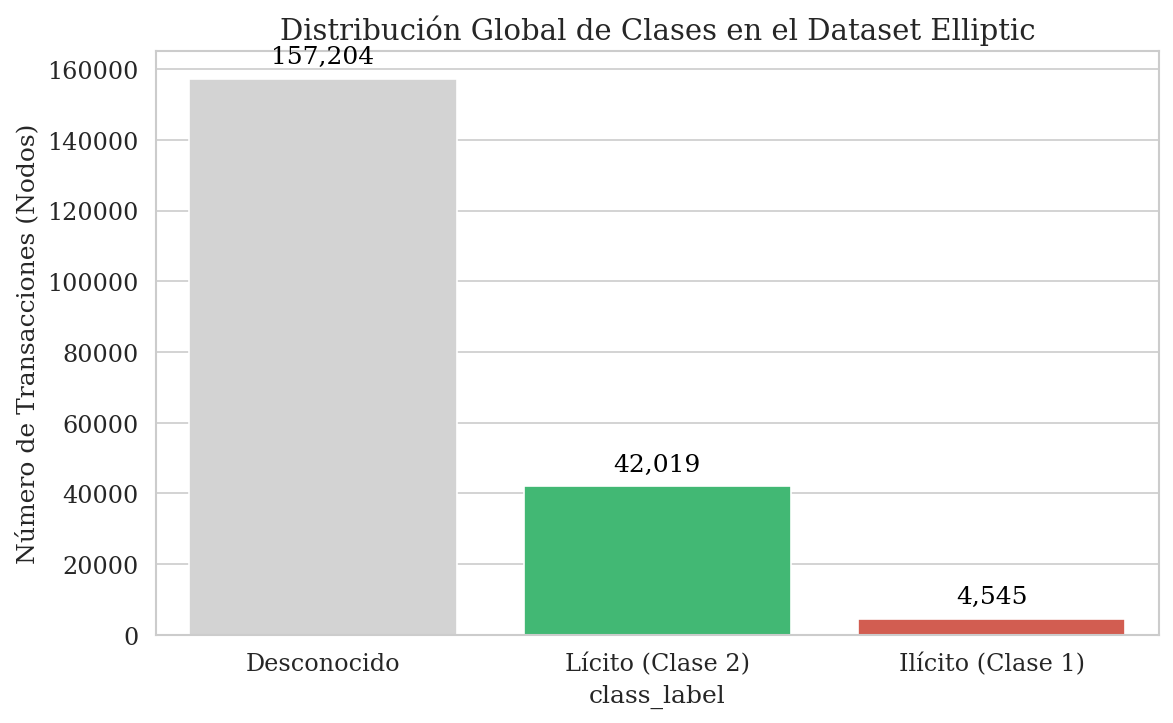

In [4]:
# 1. Ajustar columnas del df_features (no trae encabezados por defecto)
num_features = df_features.shape[1] - 2
col_names = ['txId', 'time_step'] + [f'feat_{i}' for i in range(num_features)]
df_features.columns = col_names

# 2. Mapear los nombres de las clases para mayor claridad
class_mapping = {'1': 'Ilícito (Clase 1)', '2': 'Lícito (Clase 2)', 'unknown': 'Desconocido'}
df_classes['class_label'] = df_classes['class'].map(class_mapping)

# 3. Unir las clases con su respectivo time_step
df_merged = pd.merge(df_classes, df_features[['txId', 'time_step']], on='txId', how='inner')

# 4. Calcular la distribución global
global_dist = df_merged['class_label'].value_counts()
global_dist_pct = df_merged['class_label'].value_counts(normalize=True) * 100

print("--- Distribución Global de Nodos ---")
for label, count in global_dist.items():
    print(f"{label}: {count} nodos ({global_dist_pct[label]:.2f}%)")

# Gráfico de la distribución global
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=global_dist.index, y=global_dist.values, palette=["#d3d3d3", "#2ecc71", "#e74c3c"])
plt.title('Distribución Global de Clases en el Dataset Elliptic')
plt.ylabel('Número de Transacciones (Nodos)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig('./figuras/1_distribucion_global.png')
plt.show()

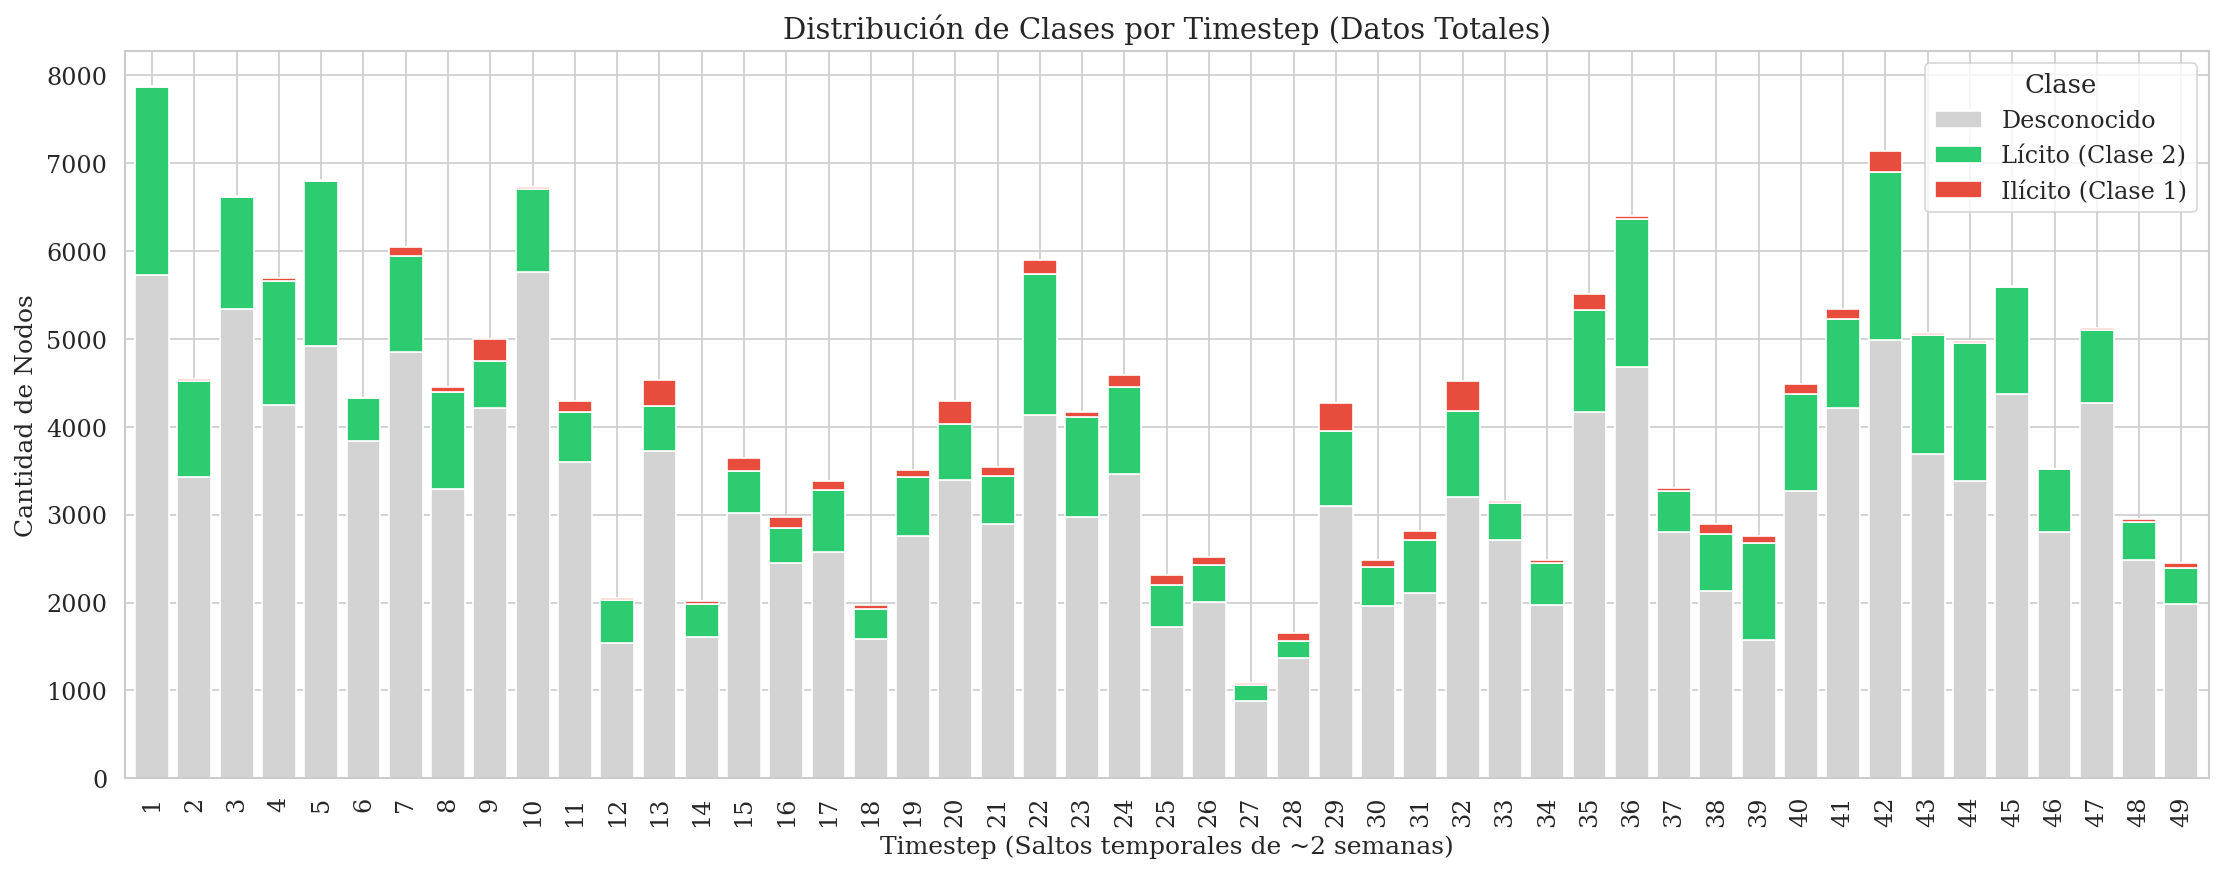

In [5]:
# Agrupar por time_step y clase
temporal_dist = df_merged.groupby(['time_step', 'class_label']).size().unstack(fill_value=0)

# Gráfico de barras apiladas a lo largo del tiempo
fig, ax = plt.subplots(figsize=(15, 6))
temporal_dist[['Desconocido', 'Lícito (Clase 2)', 'Ilícito (Clase 1)']].plot(
    kind='bar', stacked=True, color=["#d3d3d3", "#2ecc71", "#e74c3c"], ax=ax, width=0.8
)

plt.title('Distribución de Clases por Timestep (Datos Totales)')
plt.xlabel('Timestep (Saltos temporales de ~2 semanas)')
plt.ylabel('Cantidad de Nodos')
plt.xticks(rotation=90)
plt.legend(title='Clase')
plt.tight_layout()
plt.savefig('./figuras/2_distribucion_temporal_total.png')
plt.show()

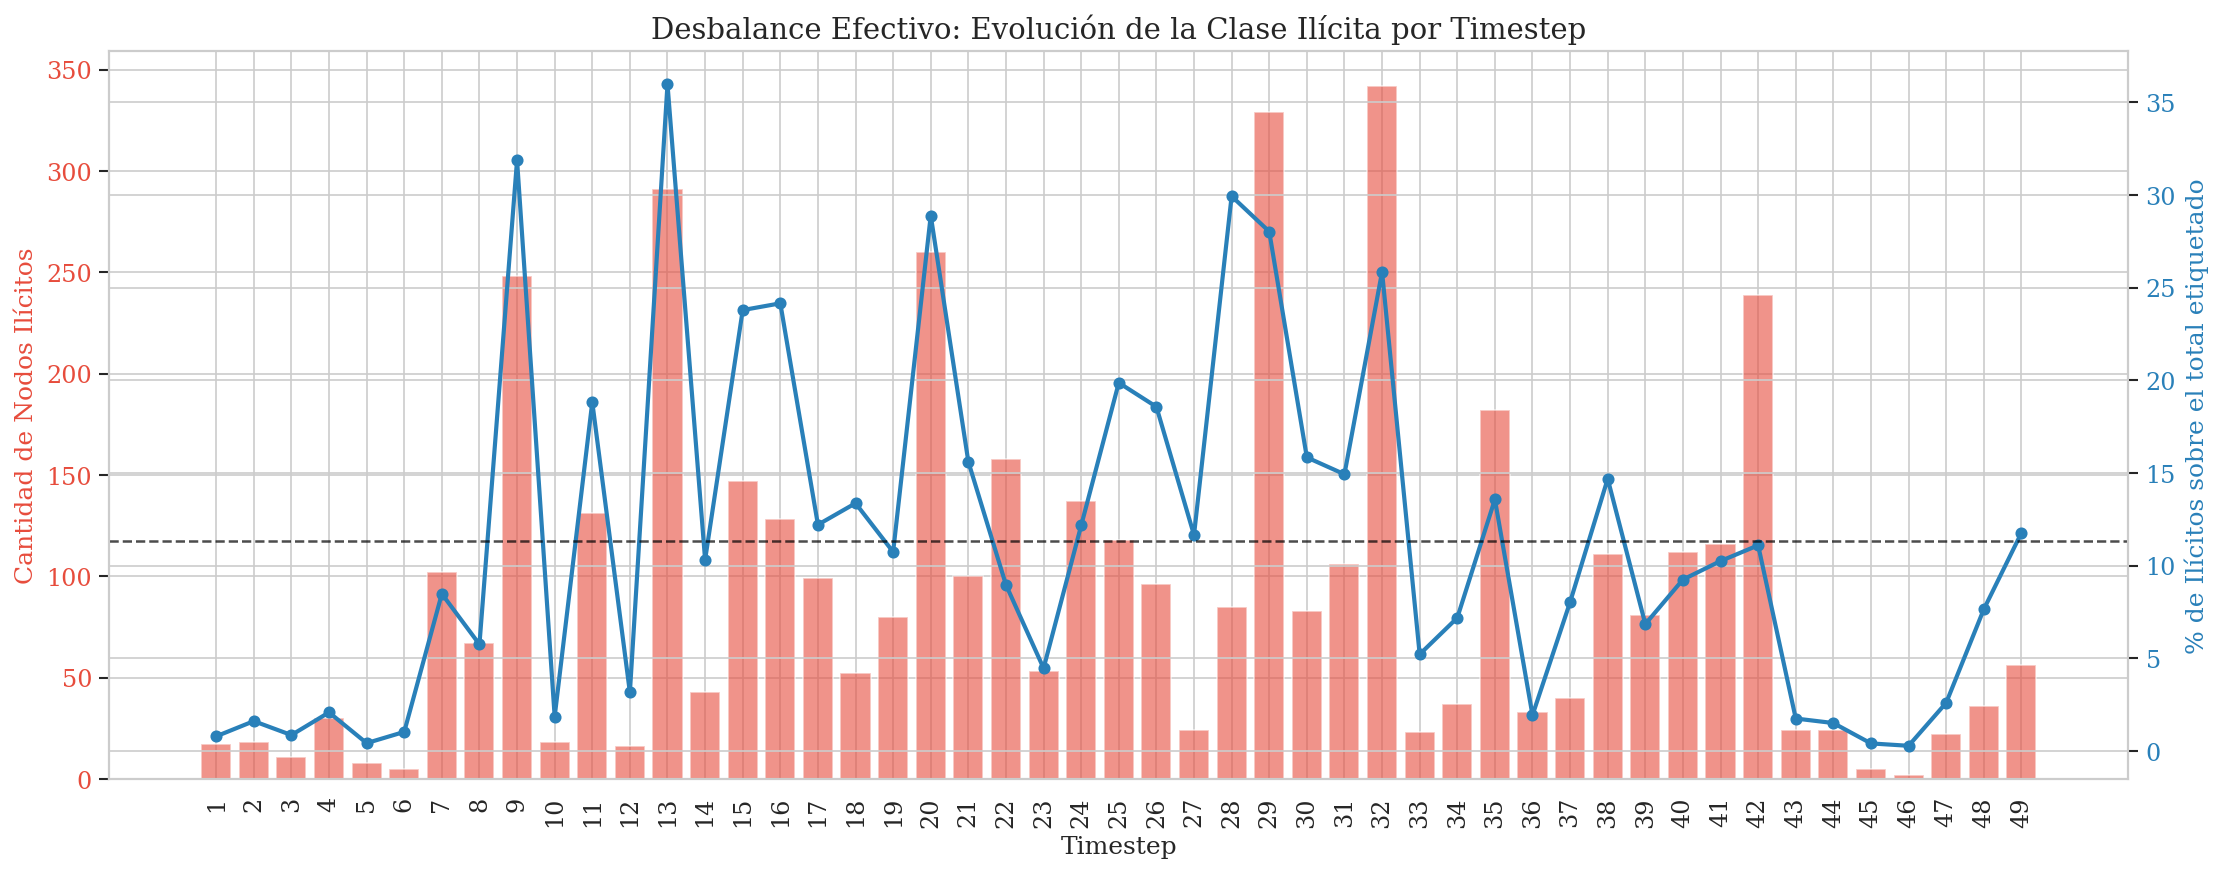


Media global de nodos ilícitos en el conjunto etiquetado: 11.35%
Timestep con MENOR % de ilícitos: 46 (0.28%)
Timestep con MAYOR % de ilícitos: 13 (35.97%)


In [6]:
# Filtrar solo los datos etiquetados (quitar 'unknown')
df_labeled = df_merged[df_merged['class'] != 'unknown']

# Calcular el porcentaje de nodos ilícitos por timestep
labeled_temporal = df_labeled.groupby(['time_step', 'class_label']).size().unstack(fill_value=0)
labeled_temporal['Total_Etiquetados'] = labeled_temporal['Lícito (Clase 2)'] + labeled_temporal['Ilícito (Clase 1)']
labeled_temporal['% Ilícito'] = (labeled_temporal['Ilícito (Clase 1)'] / labeled_temporal['Total_Etiquetados']) * 100

# Gráfico del ratio de desbalance efectivo
fig, ax1 = plt.subplots(figsize=(15, 6))

# Eje 1: Barras con la cantidad de nodos ilícitos
color1 = '#e74c3c'
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Cantidad de Nodos Ilícitos', color=color1)
ax1.bar(labeled_temporal.index, labeled_temporal['Ilícito (Clase 1)'], color=color1, alpha=0.6, label='Cantidad Ilícitos')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(labeled_temporal.index)
ax1.set_xticklabels(labeled_temporal.index, rotation=90)

# Eje 2: Línea con el porcentaje que representan sobre el total etiquetado
ax2 = ax1.twinx()  
color2 = '#2980b9'
ax2.set_ylabel('% de Ilícitos sobre el total etiquetado', color=color2)
ax2.plot(labeled_temporal.index, labeled_temporal['% Ilícito'], color=color2, marker='o', linewidth=2, label='% Ilícito')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(y=labeled_temporal['% Ilícito'].mean(), color='black', linestyle='--', alpha=0.7, label='Media % Ilícito')

plt.title('Desbalance Efectivo: Evolución de la Clase Ilícita por Timestep')
fig.tight_layout()
plt.savefig('./figuras/3_desbalance_efectivo_temporal.png')
plt.show()

print(f"\nMedia global de nodos ilícitos en el conjunto etiquetado: {labeled_temporal['% Ilícito'].mean():.2f}%")
print(f"Timestep con MENOR % de ilícitos: {labeled_temporal['% Ilícito'].idxmin()} ({labeled_temporal['% Ilícito'].min():.2f}%)")
print(f"Timestep con MAYOR % de ilícitos: {labeled_temporal['% Ilícito'].idxmax()} ({labeled_temporal['% Ilícito'].max():.2f}%)")

# 2. Distribución de Grado (In-Degree y Out-Degree)
* Qué medir: Cuántas aristas entran (dinero recibido) y cuántas salen (dinero enviado) para cada tipo de nodo (Ilícito vs. Lícito).

* Por qué es vital: En la red de Bitcoin, la topología delata la función. Los exchanges o mercados (lícitos o ilícitos) actúan como "super-nodos" (hubs) con grados altísimos, mientras que los usuarios normales o esquemas de lavado (como peeling chains) tienen firmas de grado muy específicas. Si un método XAI destaca ciertas aristas como "explicación" de por qué un nodo es ilícito, necesitas saber si el XAI simplemente está sesgado hacia nodos con un out-degree masivo, o si realmente está capturando el patrón de lavado. La distribución de grados te da la línea base (baseline) topológica.

In [7]:
# 1. Calcular Out-Degree (dinero enviado: el nodo aparece en txId1)
out_degree = df_edgelist['txId1'].value_counts().rename_axis('txId').reset_index(name='out_degree')

# 2. Calcular In-Degree (dinero recibido: el nodo aparece en txId2)
in_degree = df_edgelist['txId2'].value_counts().rename_axis('txId').reset_index(name='in_degree')

# 3. Unir los grados al dataframe de clases que creamos en el paso anterior
# Usamos left join para mantener todos los nodos, rellenando con 0 si no tienen in/out edges
df_degrees = df_classes[['txId', 'class', 'class_label']].copy()
df_degrees = df_degrees.merge(out_degree, on='txId', how='left').fillna({'out_degree': 0})
df_degrees = df_degrees.merge(in_degree, on='txId', how='left').fillna({'in_degree': 0})

# 4. Crear una columna de "Grado Total"
df_degrees['total_degree'] = df_degrees['in_degree'] + df_degrees['out_degree']

# 5. Filtrar solo los datos etiquetados para nuestra comparación Lícito vs Ilícito
df_labeled_degrees = df_degrees[df_degrees['class'] != 'unknown']

print("Resumen estadístico de grados para nodos Lícitos:")
print(df_labeled_degrees[df_labeled_degrees['class'] == '2'][['in_degree', 'out_degree']].describe())
print("\nResumen estadístico de grados para nodos Ilícitos:")
print(df_labeled_degrees[df_labeled_degrees['class'] == '1'][['in_degree', 'out_degree']].describe())

Resumen estadístico de grados para nodos Lícitos:
          in_degree    out_degree
count  42019.000000  42019.000000
mean       1.909398      1.185821
std        7.122538      3.246769
min        0.000000      0.000000
25%        0.000000      1.000000
50%        1.000000      1.000000
75%        1.000000      1.000000
max      284.000000    472.000000

Resumen estadístico de grados para nodos Ilícitos:
         in_degree   out_degree
count  4545.000000  4545.000000
mean      1.269967     0.741694
std       7.215218     0.571620
min       0.000000     0.000000
25%       0.000000     0.000000
50%       1.000000     1.000000
75%       1.000000     1.000000
max     177.000000     3.000000


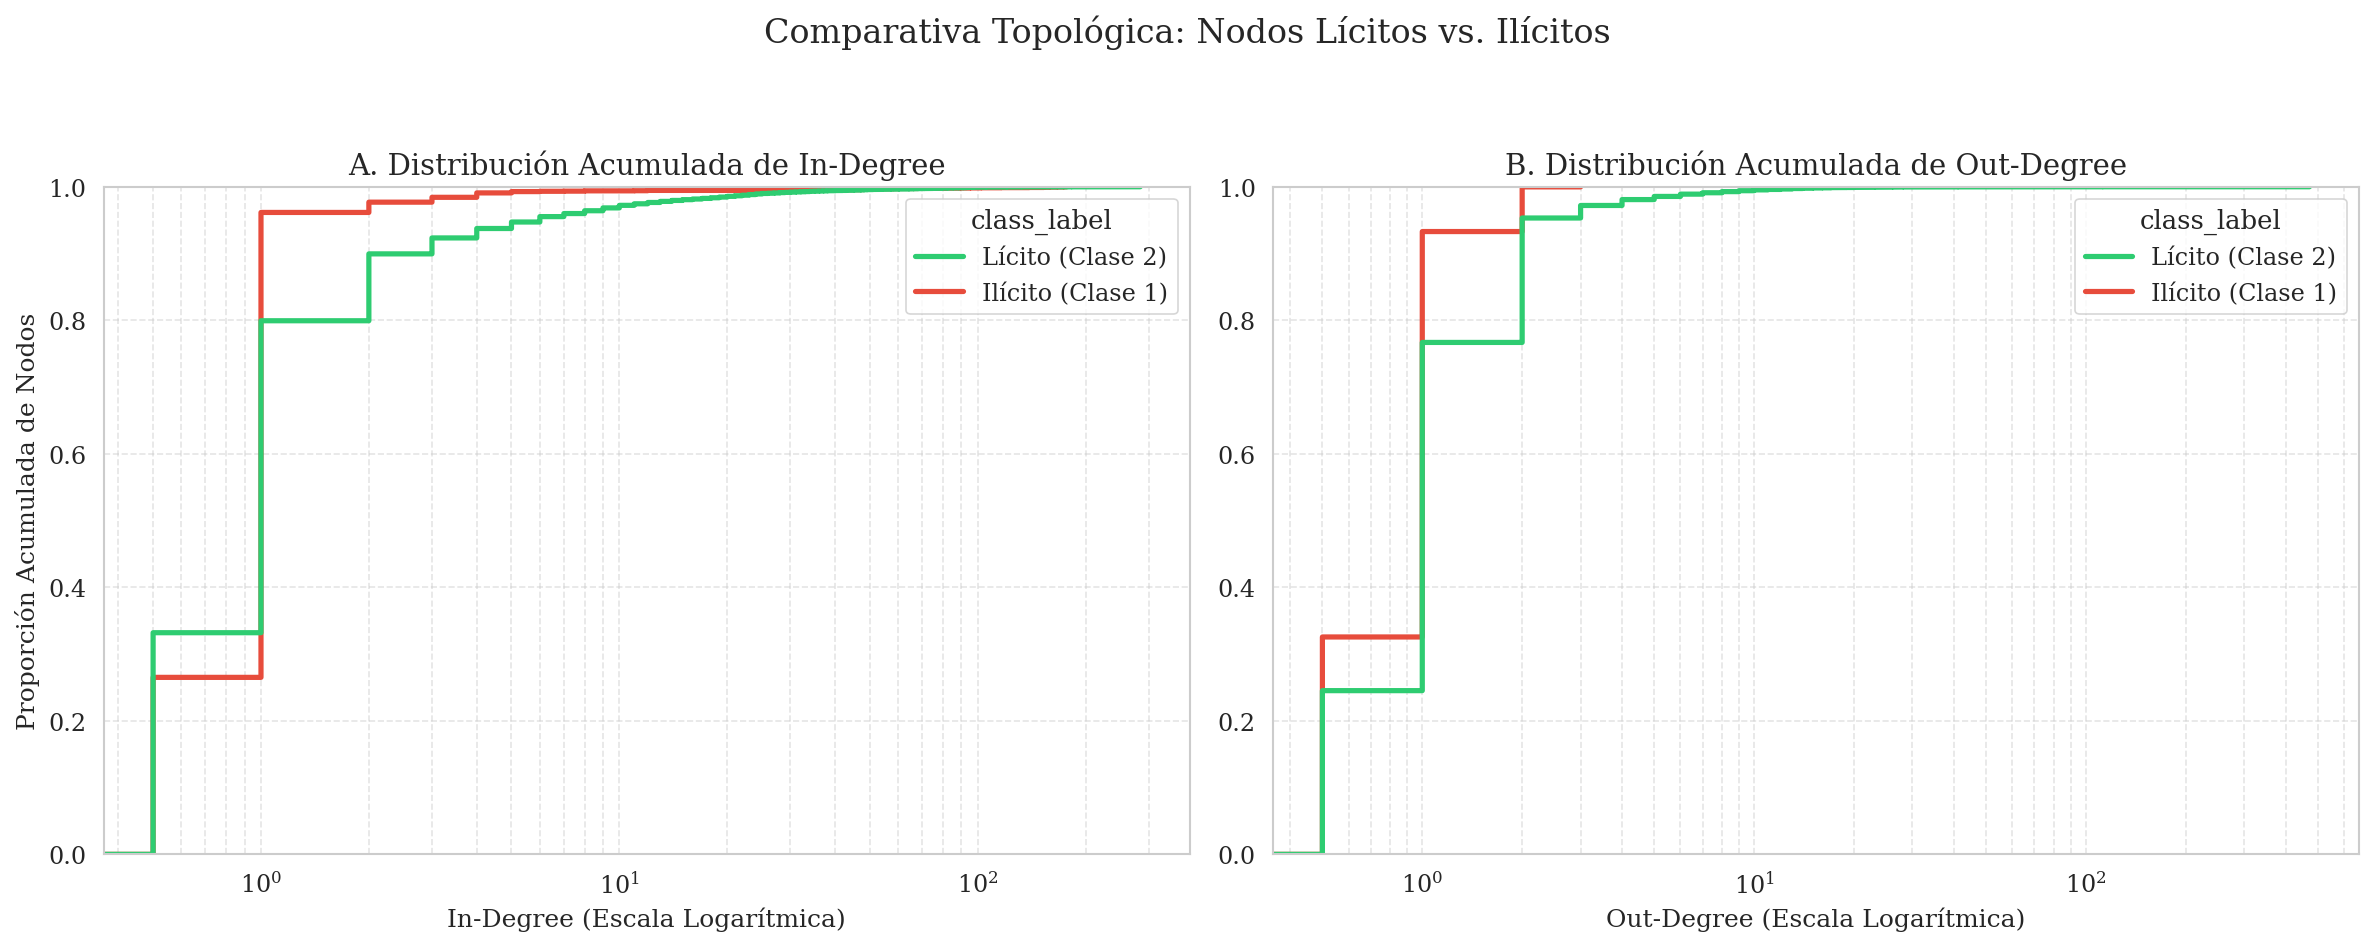

In [9]:
# 1. Ajustar ceros a un valor ínfimo solo para que la escala logarítmica no arroje error
df_labeled_degrees_viz = df_labeled_degrees.copy()
df_labeled_degrees_viz['in_degree'] = df_labeled_degrees_viz['in_degree'].replace(0, 0.5)
df_labeled_degrees_viz['out_degree'] = df_labeled_degrees_viz['out_degree'].replace(0, 0.5)

# 2. Configurar el lienzo para dos subgráficos horizontales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: ECDF para In-Degree
sns.ecdfplot(
    data=df_labeled_degrees_viz, 
    x='in_degree', 
    hue='class_label', 
    palette=["#2ecc71", "#e74c3c"], 
    ax=axes[0], 
    linewidth=2.5
)
axes[0].set_xscale('log')
axes[0].set_title('A. Distribución Acumulada de In-Degree')
axes[0].set_xlabel('In-Degree (Escala Logarítmica)')
axes[0].set_ylabel('Proporción Acumulada de Nodos')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Gráfico 2: ECDF para Out-Degree
sns.ecdfplot(
    data=df_labeled_degrees_viz, 
    x='out_degree', 
    hue='class_label', 
    palette=["#2ecc71", "#e74c3c"], 
    ax=axes[1], 
    linewidth=2.5
)
axes[1].set_xscale('log')
axes[1].set_title('B. Distribución Acumulada de Out-Degree')
axes[1].set_xlabel('Out-Degree (Escala Logarítmica)')
axes[1].set_ylabel('') # Ocultar para no ser redundante
axes[1].grid(True, which="both", ls="--", alpha=0.5)

plt.suptitle('Comparativa Topológica: Nodos Lícitos vs. Ilícitos', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('./figuras/4_distribucion_grados_ecdf.png', bbox_inches='tight')
plt.show()

Construyendo el grafo dirigido...
Grafo listo: 203,769 nodos y 234,355 aristas.



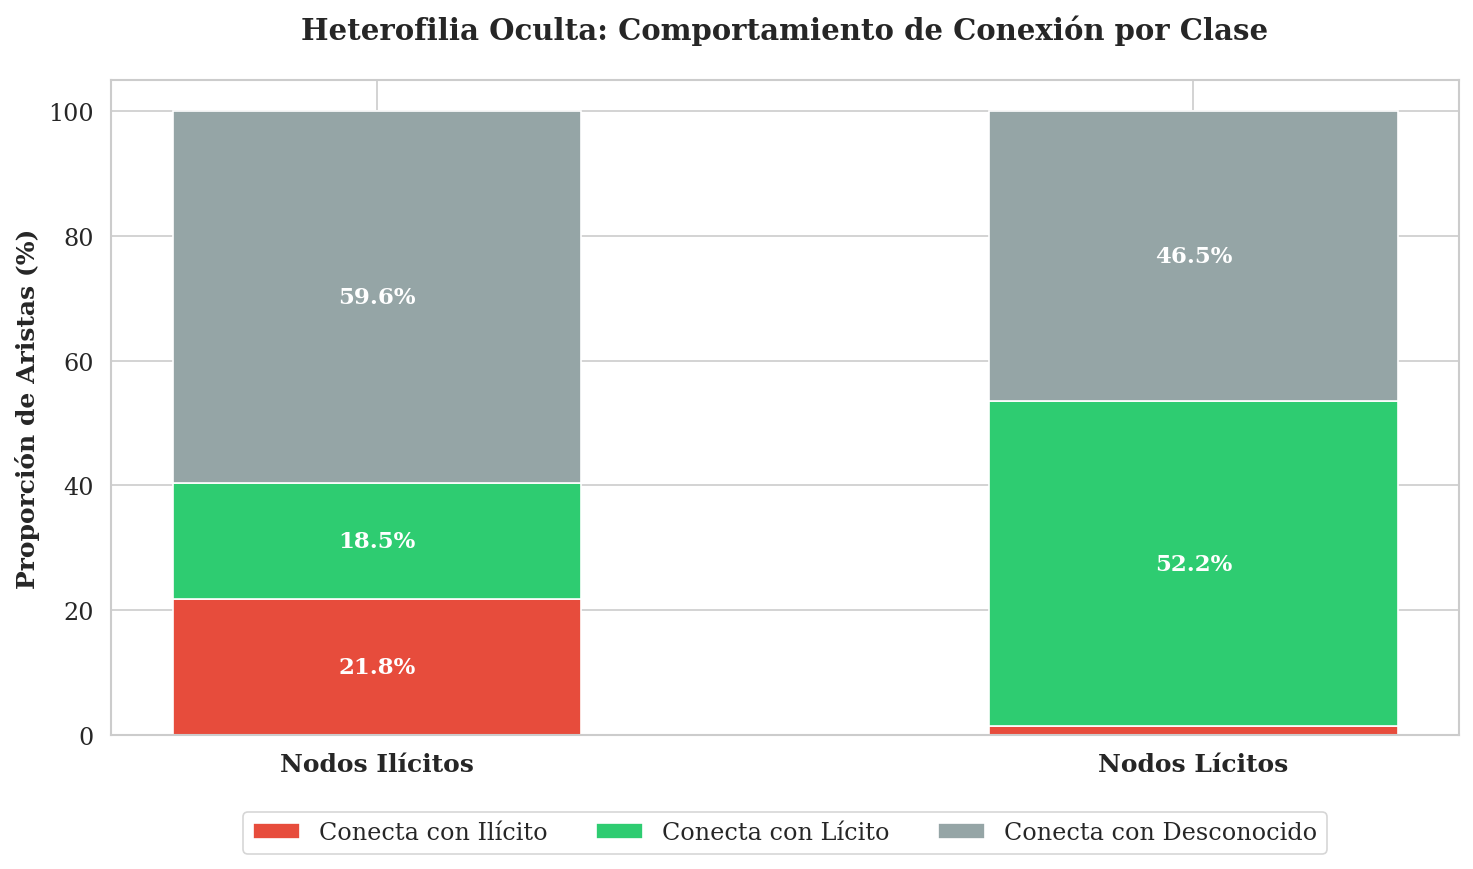

=== Análisis de Homofilia Específica (Aristas Totales) ===
Total de conexiones que involucran a un nodo ILÍCITO: 9,143
  -> A otros Ilícitos (Homofilia Real): 1,996 (21.83%)
  -> A Lícitos (Heterofilia): 1,696 (18.55%)
  -> A Desconocidos (Ocultamiento): 5,451 (59.62%)
--------------------------------------------------
Total de conexiones que involucran a un nodo LÍCITO: 130,058
  -> A otros Lícitos (Homofilia): 67,860 (52.18%)
  -> A Ilícitos (Heterofilia): 1,696 (1.30%)


In [11]:
import networkx as nx

# ==========================================
# 1. CONSTRUCCIÓN DEL GRAFO G
# ==========================================
print("Construyendo el grafo dirigido...")
G = nx.DiGraph() 

# Añadir todas las aristas desde el DataFrame
G.add_edges_from(zip(df_edgelist['txId1'], df_edgelist['txId2']))

# Mapear las clases a enteros para que la función matemática las procese rápido
# '1': Ilícito -> 1, '2': Lícito -> 2, 'unknown': Desconocido -> -1
label_mapping = {'1': 1, '2': 2, 'unknown': -1}
node_labels = df_classes.set_index('txId')['class'].map(label_mapping).to_dict()

# Inyectar las etiquetas como atributos de los nodos en el grafo
nx.set_node_attributes(G, node_labels, 'label')

print(f"Grafo listo: {G.number_of_nodes():,} nodos y {G.number_of_edges():,} aristas.\n")

# ==========================================
# 2. CÁLCULO DE HOMOFILIA ESPECÍFICA
# ==========================================
def class_specific_homophily(G, label_attr='label'):
    edge_counts = {
        'illicit': {'to_illicit': 0, 'to_licit': 0, 'to_unknown': 0},
        'licit':   {'to_illicit': 0, 'to_licit': 0, 'to_unknown': 0}
    }

    for u, v in G.edges():
        lu = G.nodes[u].get(label_attr, -1)
        lv = G.nodes[v].get(label_attr, -1)
        
        # Identificar qué es cada nodo
        str_lu = 'illicit' if lu == 1 else ('licit' if lu == 2 else 'unknown')
        str_lv = 'illicit' if lv == 1 else ('licit' if lv == 2 else 'unknown')
        
        # Sumar desde la perspectiva del nodo origen (Out-edges)
        if str_lu != 'unknown':
            edge_counts[str_lu][f'to_{str_lv}'] += 1
            
        # Sumar desde la perspectiva del nodo destino (In-edges)
        if str_lv != 'unknown':
           edge_counts[str_lv][f'to_{str_lu}'] += 1

    return edge_counts

# Ejecutar el cálculo ahora que G existe
edge_stats = class_specific_homophily(G)

# ==========================================
# 3. VISUALIZACIÓN
# ==========================================
# Datos en porcentajes para Ilícitos
illicit_total = sum(edge_stats['illicit'].values())
illicit_pcts = [
    (edge_stats['illicit']['to_illicit'] / illicit_total) * 100 if illicit_total > 0 else 0,
    (edge_stats['illicit']['to_licit'] / illicit_total) * 100 if illicit_total > 0 else 0,
    (edge_stats['illicit']['to_unknown'] / illicit_total) * 100 if illicit_total > 0 else 0
]

# Datos en porcentajes para Lícitos
licit_total = sum(edge_stats['licit'].values())
licit_pcts = [
    (edge_stats['licit']['to_illicit'] / licit_total) * 100 if licit_total > 0 else 0,
    (edge_stats['licit']['to_licit'] / licit_total) * 100 if licit_total > 0 else 0,
    (edge_stats['licit']['to_unknown'] / licit_total) * 100 if licit_total > 0 else 0
]

# Crear el gráfico
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.5
r1 = [0, 1]
classes_labels = ['Nodos Ilícitos', 'Nodos Lícitos']

# Barras apiladas
p1 = ax.bar(r1, [illicit_pcts[0], licit_pcts[0]], color='#e74c3c', edgecolor='white', width=bar_width, label='Conecta con Ilícito')
p2 = ax.bar(r1, [illicit_pcts[1], licit_pcts[1]], bottom=[illicit_pcts[0], licit_pcts[0]], color='#2ecc71', edgecolor='white', width=bar_width, label='Conecta con Lícito')
p3 = ax.bar(r1, [illicit_pcts[2], licit_pcts[2]], bottom=[illicit_pcts[0]+illicit_pcts[1], licit_pcts[0]+licit_pcts[1]], color='#95a5a6', edgecolor='white', width=bar_width, label='Conecta con Desconocido')

plt.title('Heterofilia Oculta: Comportamiento de Conexión por Clase', fontweight='bold', pad=20)
plt.ylabel('Proporción de Aristas (%)', fontweight='bold')
plt.xticks(r1, classes_labels, fontweight='bold', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

# Añadir etiquetas de porcentaje dentro de las barras (solo > 3% para no saturar)
for r in [p1, p2, p3]:
    for rect in r:
        height = rect.get_height()
        if height > 3:
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, rect.get_y() + height / 2),
                        xytext=(0, 0),  
                        textcoords="offset points",
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./figuras/3_homofilia_especifica_clase.png', bbox_inches='tight')
plt.show()

# Imprimir las estadísticas crudas para incluirlas en el texto de tu tesis
print("=== Análisis de Homofilia Específica (Aristas Totales) ===")
print(f"Total de conexiones que involucran a un nodo ILÍCITO: {illicit_total:,}")
print(f"  -> A otros Ilícitos (Homofilia Real): {edge_stats['illicit']['to_illicit']:,} ({illicit_pcts[0]:.2f}%)")
print(f"  -> A Lícitos (Heterofilia): {edge_stats['illicit']['to_licit']:,} ({illicit_pcts[1]:.2f}%)")
print(f"  -> A Desconocidos (Ocultamiento): {edge_stats['illicit']['to_unknown']:,} ({illicit_pcts[2]:.2f}%)")
print("-" * 50)
print(f"Total de conexiones que involucran a un nodo LÍCITO: {licit_total:,}")
print(f"  -> A otros Lícitos (Homofilia): {edge_stats['licit']['to_licit']:,} ({licit_pcts[1]:.2f}%)")
print(f"  -> A Ilícitos (Heterofilia): {edge_stats['licit']['to_illicit']:,} ({licit_pcts[0]:.2f}%)")

# 4. Dinámica Temporal de la Topología (Densidad por Timestep)
* Qué medir: El dataset Elliptic está dividido en 49 timesteps (instantáneas temporales de aproximadamente 2 semanas cada una). Debes medir cómo cambia la densidad del grafo, el número de componentes conectados y el volumen de transacciones en cada salto temporal.

* Por qué es vital: El comportamiento financiero no es estático. Se sabe que en el Elliptic Dataset hay un evento disruptivo (el cierre de un mercado de la dark web alrededor del timestep 43) que cambia drásticamente la estructura de la red y hace que la precisión de los modelos caiga. Si evalúas la "estabilidad de los métodos XAI", debes demostrar que tus explicaciones son coherentes antes, durante y después de cambios estructurales abruptos en la red. El análisis temporal del EDA te marcará los puntos de quiebre donde debes probar el estrés de tus modelos.

Calculando métricas topológicas por timestep... (Esto puede tardar un par de minutos)
Cálculo completado. Generando gráfica...


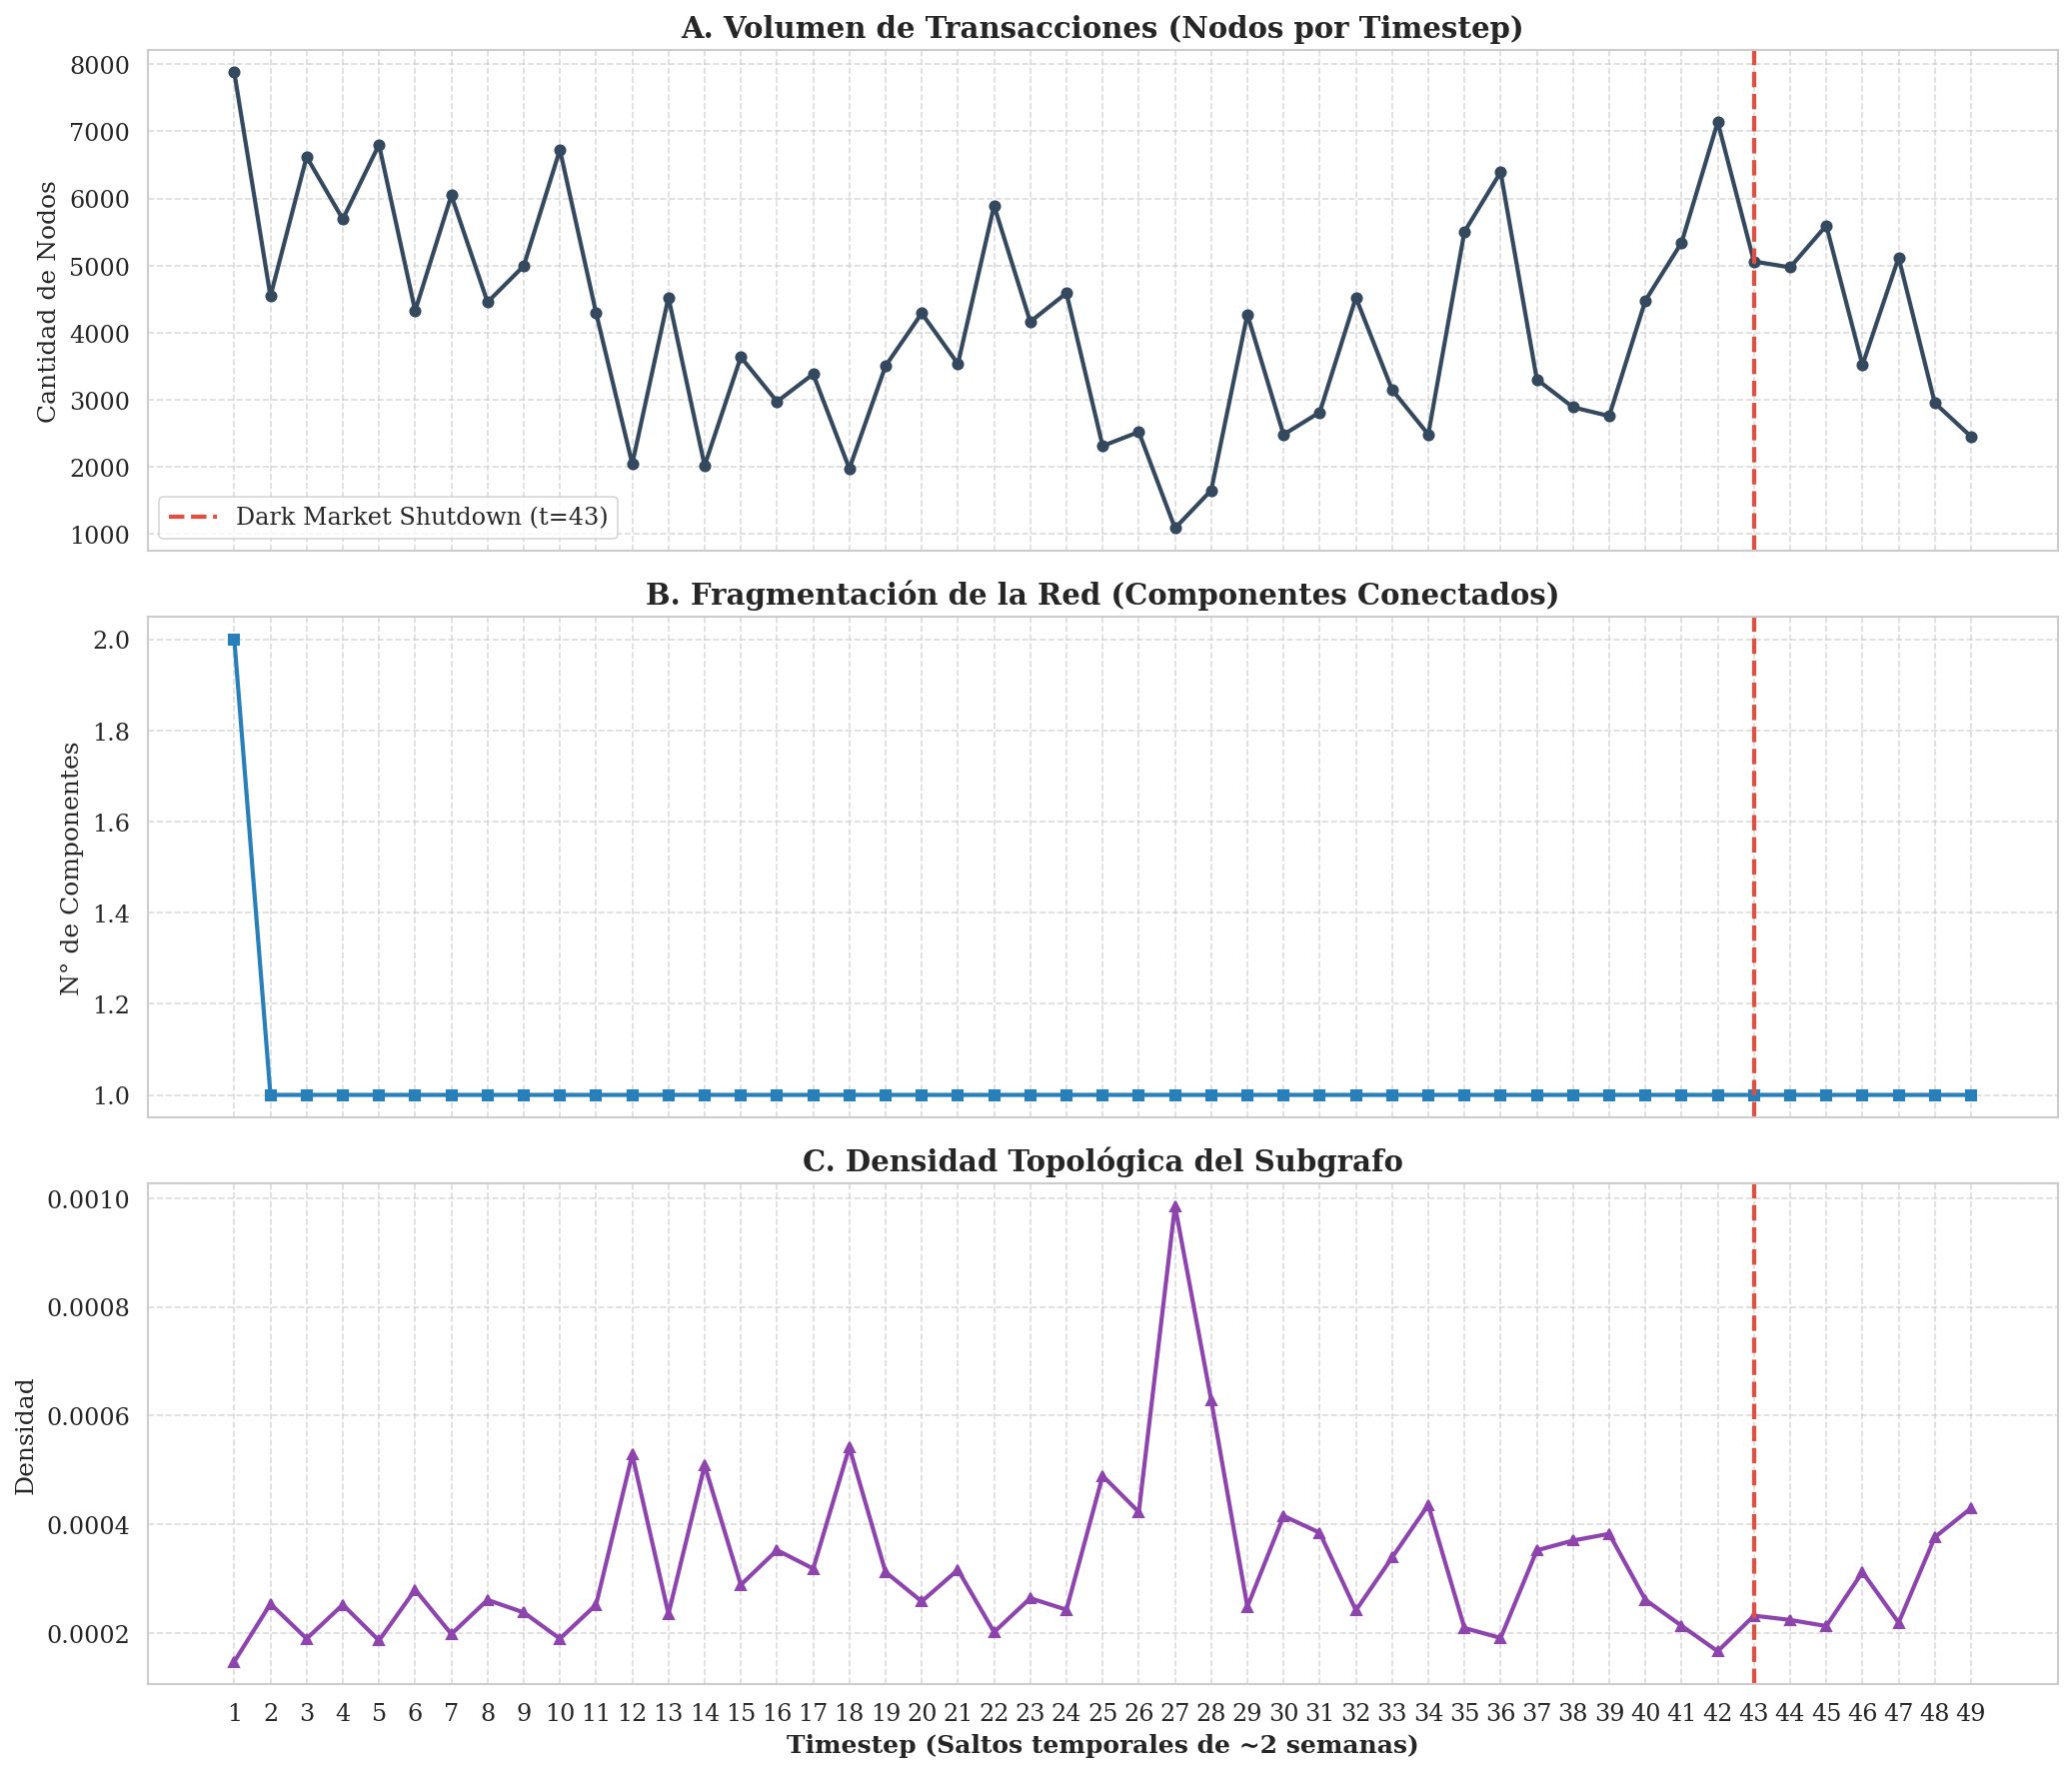

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Asumimos que el grafo dirigido G y df_merged (con 'txId' y 'time_step') ya existen del paso anterior.

print("Calculando métricas topológicas por timestep... (Esto puede tardar un par de minutos)")

timesteps = sorted(df_merged['time_step'].unique())
temporal_metrics = []

for t in timesteps:
    # 1. Extraer los nodos que pertenecen a este timestep
    nodes_t = df_merged[df_merged['time_step'] == t]['txId'].tolist()
    
    # 2. Crear un subgrafo (snapshot de la red en ese momento)
    G_t = G.subgraph(nodes_t)
    
    # 3. Calcular métricas topológicas
    num_nodes = G_t.number_of_nodes()
    num_edges = G_t.number_of_edges()
    
    # Densidad: relación entre aristas reales vs aristas posibles
    density = nx.density(G_t) 
    
    # Componentes débilmente conectados (subredes aisladas dentro de ese timestep)
    # Usamos weakly connected porque es un grafo dirigido
    components = nx.number_weakly_connected_components(G_t) if num_nodes > 0 else 0
    
    temporal_metrics.append({
        'time_step': t,
        'num_nodes': num_nodes,
        'num_edges': num_edges,
        'density': density,
        'components': components
    })

df_metrics = pd.DataFrame(temporal_metrics)
print("Cálculo completado. Generando gráfica...")

# ==========================================
# VISUALIZACIÓN MULTIPANEL PARA LA TESIS
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Evento disruptivo documentado en la literatura de Elliptic
shock_timestep = 43 

# 1. Volumen de la Red (Nodos)
axes[0].plot(df_metrics['time_step'], df_metrics['num_nodes'], marker='o', color='#34495e', linewidth=2)
axes[0].set_title('A. Volumen de Transacciones (Nodos por Timestep)', fontweight='bold')
axes[0].set_ylabel('Cantidad de Nodos')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].axvline(x=shock_timestep, color='#e74c3c', linestyle='--', linewidth=2, label='Dark Market Shutdown (t=43)')
axes[0].legend()

# 2. Componentes Conectados (Fragmentación)
axes[1].plot(df_metrics['time_step'], df_metrics['components'], marker='s', color='#2980b9', linewidth=2)
axes[1].set_title('B. Fragmentación de la Red (Componentes Conectados)', fontweight='bold')
axes[1].set_ylabel('N° de Componentes')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].axvline(x=shock_timestep, color='#e74c3c', linestyle='--', linewidth=2)

# 3. Densidad del Grafo
axes[2].plot(df_metrics['time_step'], df_metrics['density'], marker='^', color='#8e44ad', linewidth=2)
axes[2].set_title('C. Densidad Topológica del Subgrafo', fontweight='bold')
axes[2].set_xlabel('Timestep (Saltos temporales de ~2 semanas)', fontweight='bold')
axes[2].set_ylabel('Densidad')
axes[2].grid(True, linestyle='--', alpha=0.7)
axes[2].axvline(x=shock_timestep, color='#e74c3c', linestyle='--', linewidth=2)

plt.xticks(timesteps)
plt.tight_layout()
plt.savefig('./figuras/5_dinamica_temporal_topologia.png', bbox_inches='tight')
plt.show()

Preparando el dataset completo con las 165 variables...
Dataset listo: 46564 filas y 165 características (features).
Entrenando Random Forest... (Esto tomará unos 10-20 segundos)


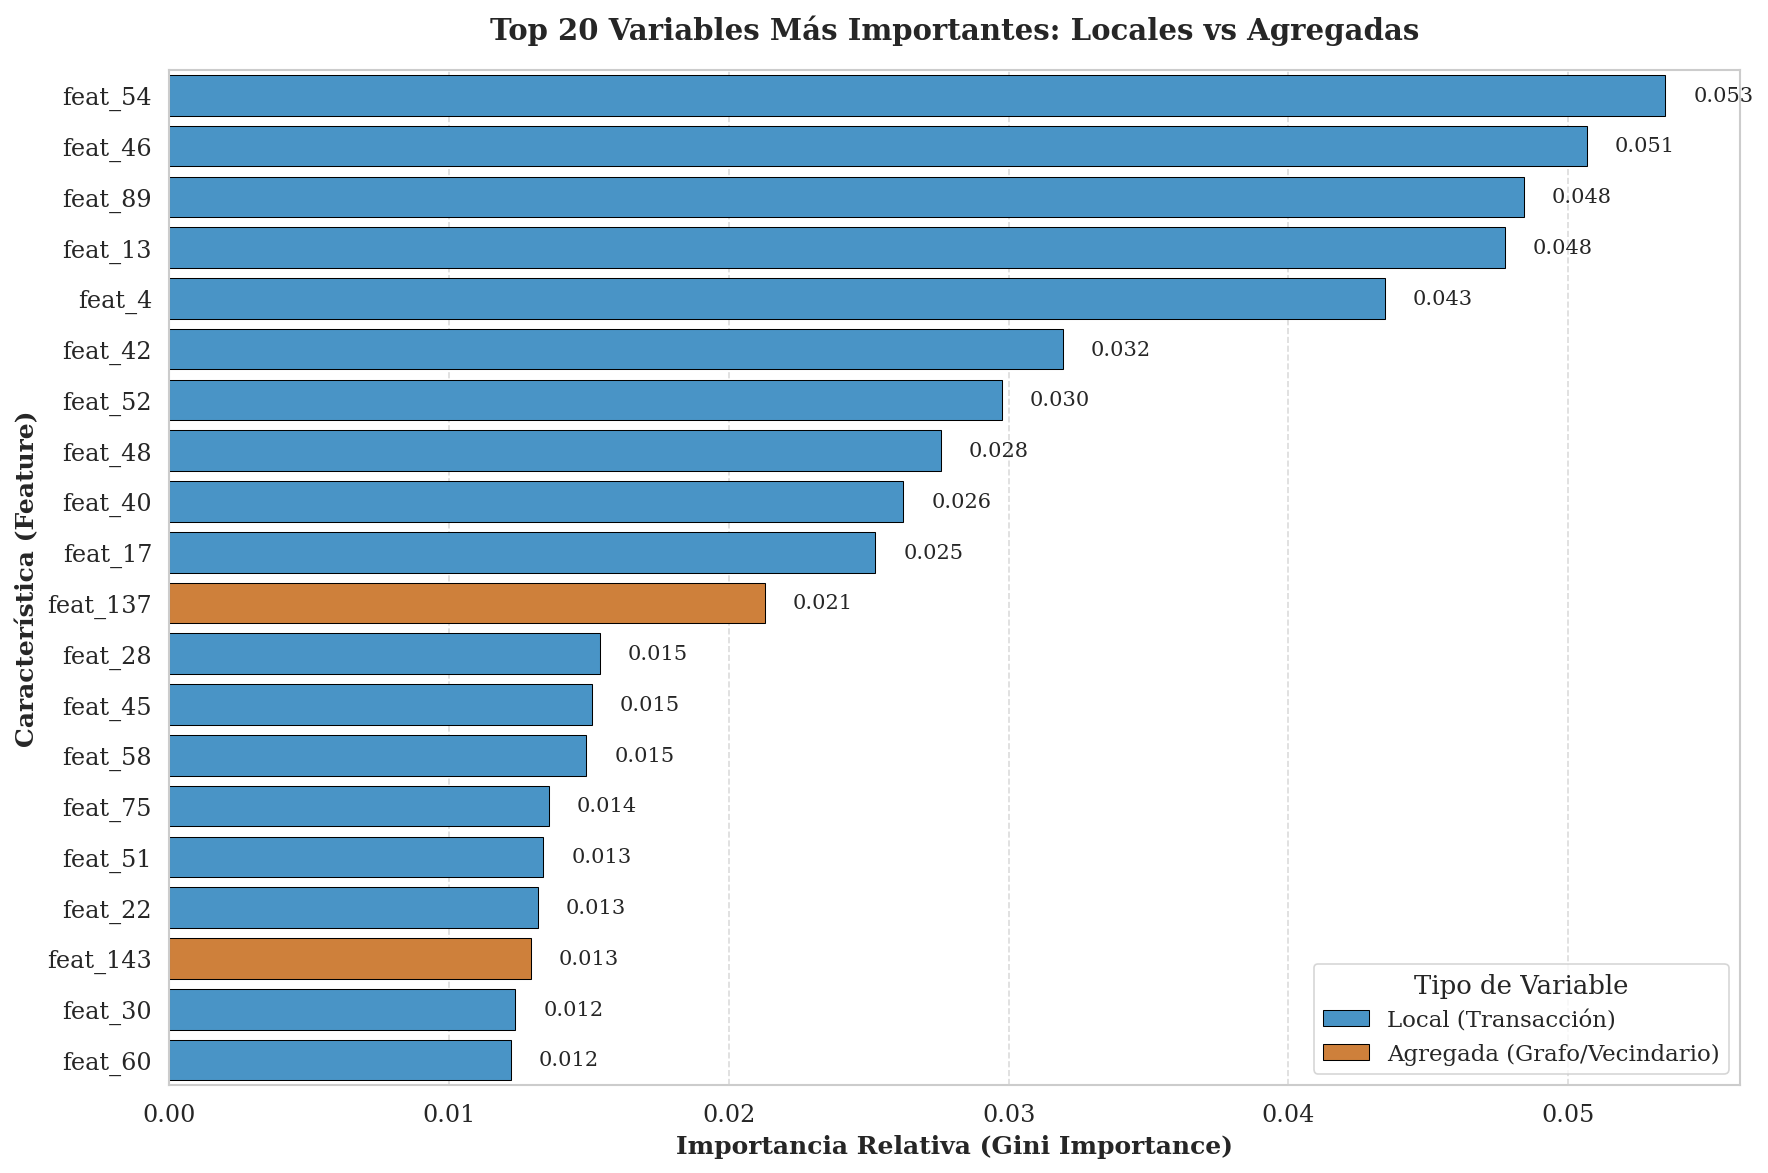

--------------------------------------------------
En el Top 10 de variables más importantes, 10 son Locales y 0 son Agregadas.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.patches as mpatches

print("Preparando el dataset completo con las 165 variables...")

# 1. Unir df_classes con el df_features COMPLETO
# Asegurarnos de usar df_features que ya tiene los nombres de columnas (feat_0 a feat_164)
df_full = pd.merge(df_classes, df_features, on='txId', how='inner')

# 2. Filtrar solo los datos etiquetados (quitar 'unknown')
df_full_labeled = df_full[df_full['class'] != 'unknown'].copy()

# 3. Separar variables predictoras (X) y variable objetivo (y)
# Quitamos txId, time_step, class y class_label (si existe)
cols_to_drop = ['txId', 'time_step', 'class']
if 'class_label' in df_full_labeled.columns:
    cols_to_drop.append('class_label')

X = df_full_labeled.drop(columns=cols_to_drop)
y = df_full_labeled['class'].astype(int)

print(f"Dataset listo: {X.shape[0]} filas y {X.shape[1]} características (features).")
print("Entrenando Random Forest... (Esto tomará unos 10-20 segundos)")

# 4. Entrenar el modelo
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight='balanced', n_jobs=-1)
rf.fit(X, y)

# 5. Extraer y clasificar la importancia
importances = rf.feature_importances_
feature_names = X.columns

feat_data = []
for i, (name, imp) in enumerate(zip(feature_names, importances)):
    # En Elliptic, las primeras 93 features (0 a 92) son Locales, el resto Agregadas
    feat_type = 'Local (Transacción)' if i < 93 else 'Agregada (Grafo/Vecindario)'
    feat_data.append({'Feature': name, 'Importance': imp, 'Type': feat_type})

df_imp = pd.DataFrame(feat_data)
df_imp = df_imp.sort_values(by='Importance', ascending=False).head(20) # Tomar el Top 20

# 6. Visualización de Alto Impacto
fig, ax = plt.subplots(figsize=(12, 8))

# Asignar colores: Azul para Locales, Naranja para Agregadas
colores = {'Local (Transacción)': '#3498db', 'Agregada (Grafo/Vecindario)': '#e67e22'}

# La forma moderna (y sin errores) de Seaborn
sns.barplot(
    data=df_imp, 
    x='Importance', 
    y='Feature', 
    hue='Type',          # <--- Le decimos a Seaborn que agrupe por 'Type'
    palette=colores,     # <--- Pasamos el diccionario directamente
    dodge=False,         # <--- Evitamos que mueva las barras de su eje Y
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Top 20 Variables Más Importantes: Locales vs Agregadas', fontweight='bold', pad=15)
plt.xlabel('Importancia Relativa (Gini Importance)', fontweight='bold')
plt.ylabel('Característica (Feature)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir el porcentaje exacto al lado de cada barra
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Seaborn moderno con hue a veces crea barras invisibles (width 0), las ignoramos
    if width > 0: 
        ax.text(width + 0.001, p.get_y() + p.get_height() / 2, 
                f'{width:.3f}', ha='left', va='center', fontsize=10)

# Seaborn ya genera la leyenda automáticamente gracias al parámetro 'hue'
ax.legend(title='Tipo de Variable', loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('./figuras/6_importancia_caracteristicas.png', bbox_inches='tight')
plt.show()

# Imprimir un resumen
top_10 = df_imp.head(10)
locales_en_top = sum(top_10['Type'] == 'Local (Transacción)')
print("-" * 50)
print(f"En el Top 10 de variables más importantes, {locales_en_top} son Locales y {10 - locales_en_top} son Agregadas.")

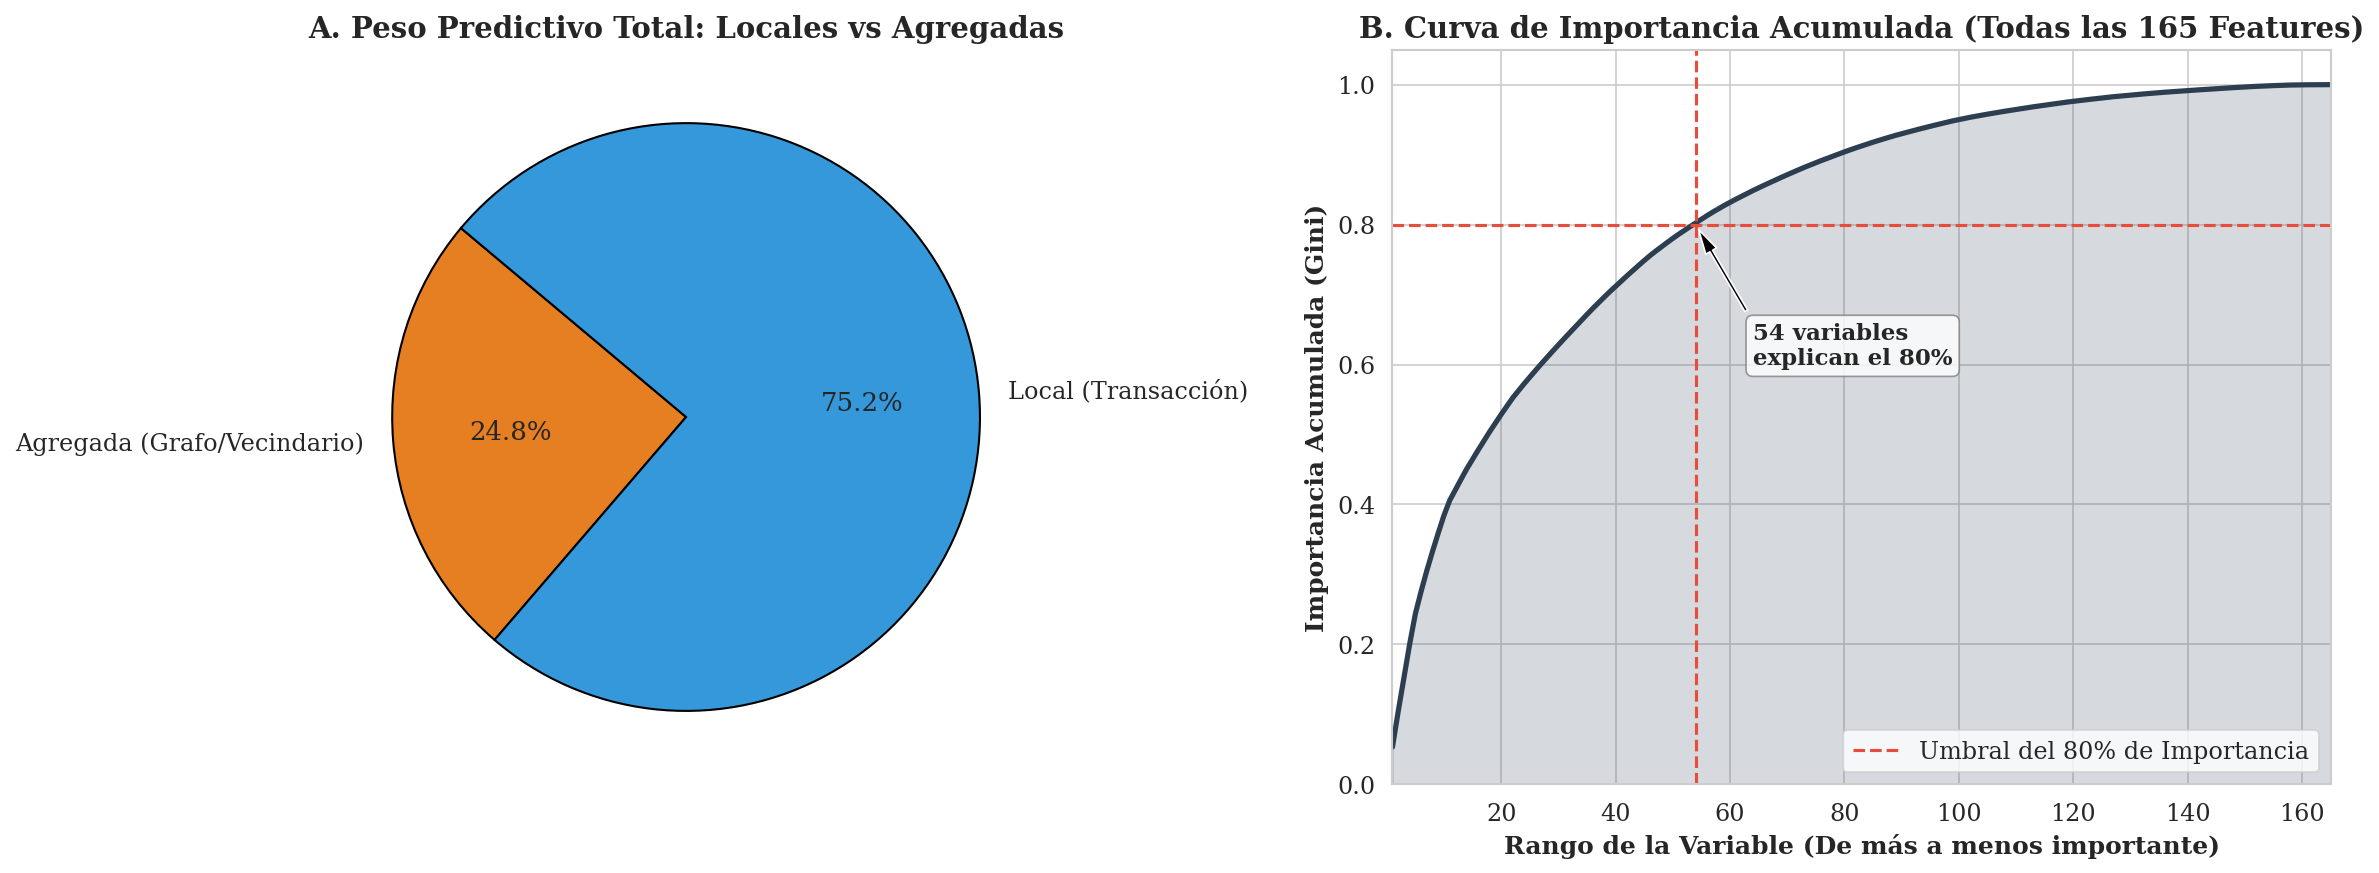

=== Análisis de Dispersión Predictiva ===
Número total de variables evaluadas: 165
Para alcanzar el 80% del poder predictivo, el modelo solo necesita el top 54 variables.
De esas 54 variables top, 37 son Locales y 17 son Agregadas.


In [16]:
# 1. Recrear el DataFrame completo de importancias (sin recortar al Top 20)
feat_data_full = []
for i, (name, imp) in enumerate(zip(X.columns, rf.feature_importances_)):
    feat_type = 'Local (Transacción)' if i < 93 else 'Agregada (Grafo/Vecindario)'
    feat_data_full.append({'Feature': name, 'Importance': imp, 'Type': feat_type})

df_imp_full = pd.DataFrame(feat_data_full).sort_values(by='Importance', ascending=False)
df_imp_full['Cumulative_Importance'] = df_imp_full['Importance'].cumsum()
df_imp_full['Rank'] = range(1, len(df_imp_full) + 1)

# ==========================================
# VISUALIZACIÓN DUAL DE TODAS LAS FEATURES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Peso Total por Categoría (Suma de Gini) ---
suma_importancia = df_imp_full.groupby('Type')['Importance'].sum() * 100 # En porcentaje

# Colores consistentes
colores_pie = ['#e67e22', '#3498db'] if suma_importancia.index[0] == 'Agregada (Grafo/Vecindario)' else ['#3498db', '#e67e22']

axes[0].pie(
    suma_importancia, 
    labels=suma_importancia.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colores_pie,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[0].set_title('A. Peso Predictivo Total: Locales vs Agregadas', fontweight='bold')

# --- Gráfico 2: Curva de Importancia Acumulada (Pareto) ---
sns.lineplot(
    data=df_imp_full, 
    x='Rank', 
    y='Cumulative_Importance', 
    ax=axes[1], 
    color='#2c3e50', 
    linewidth=2.5
)
axes[1].fill_between(df_imp_full['Rank'], df_imp_full['Cumulative_Importance'], alpha=0.2, color='#34495e')

# Línea del 80% de varianza explicada
axes[1].axhline(y=0.80, color='#e74c3c', linestyle='--', linewidth=1.5, label='Umbral del 80% de Importancia')

# Encontrar cuántas variables se necesitan para llegar al 80%
num_vars_80 = df_imp_full[df_imp_full['Cumulative_Importance'] >= 0.80].iloc[0]['Rank']
axes[1].axvline(x=num_vars_80, color='#e74c3c', linestyle='--', linewidth=1.5)

axes[1].set_title('B. Curva de Importancia Acumulada (Todas las 165 Features)', fontweight='bold')
axes[1].set_xlabel('Rango de la Variable (De más a menos importante)', fontweight='bold')
axes[1].set_ylabel('Importancia Acumulada (Gini)', fontweight='bold')
axes[1].set_xlim(1, 165)
axes[1].set_ylim(0, 1.05)
axes[1].legend()

# Anotar el punto de corte del 80%
axes[1].annotate(
    f'{num_vars_80} variables\nexplican el 80%', 
    xy=(num_vars_80, 0.80), 
    xytext=(num_vars_80 + 10, 0.60),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
    fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

plt.tight_layout()
plt.savefig('./figuras/7_analisis_completo_features.png', bbox_inches='tight')
plt.show()

# Imprimir métricas de dispersión
print("=== Análisis de Dispersión Predictiva ===")
print(f"Número total de variables evaluadas: {len(df_imp_full)}")
print(f"Para alcanzar el 80% del poder predictivo, el modelo solo necesita el top {num_vars_80} variables.")
print(f"De esas {num_vars_80} variables top, {sum(df_imp_full.head(num_vars_80)['Type'] == 'Local (Transacción)')} son Locales y {sum(df_imp_full.head(num_vars_80)['Type'] == 'Agregada (Grafo/Vecindario)')} son Agregadas.")